In [1]:
pip install --update pip
pip install timm

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [1]:
pip install torch torchvision pytorch-lightning

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [2]:
import os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import pytorch_lightning as pl
import torch.nn.functional as F

import timm
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report


#Setting up file path
ROOT = "../fiot_highway2-main"
train_txt = os.path.join(ROOT, "train.txt")
test_txt  = os.path.join(ROOT, "test.txt")

#Initializing path extention arrays
train_data_path = pd.read_csv(train_txt, sep = "\t", header = None)
train_data_path.columns = ["extention", "class"]
test_data_path = pd.read_csv(test_txt, sep = "\t", header = None)
test_data_path.columns = ["extention", "class"]


In [3]:
#Checking for correct columns
train_data_path.head()

,extention,class
0,data/003719.npy,1
1,data/015802.npy,2
2,data/015920.npy,2
3,data/000663.npy,0
4,data/001894.npy,2


In [4]:
np.shape(train_data_path)

(12915, 2)

In [5]:
train_data_path["path"] = ROOT + "/" + train_data_path["extention"]

In [6]:
train_data_path.head()

,extention,class,path
0,data/003719.npy,1,../fiot_highway2-main/data/003719.npy
1,data/015802.npy,2,../fiot_highway2-main/data/015802.npy
2,data/015920.npy,2,../fiot_highway2-main/data/015920.npy
3,data/000663.npy,0,../fiot_highway2-main/data/000663.npy
4,data/001894.npy,2,../fiot_highway2-main/data/001894.npy


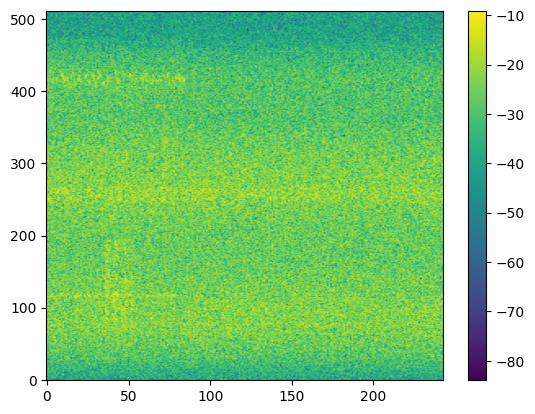

In [7]:
#testing through a quick visualization
train_data_path["path"][0]
temp = np.load(train_data_path["path"][0])
plt.imshow(temp, aspect='auto', origin='lower')
plt.colorbar()
plt.show()

In [8]:
np.shape(temp)

(512, 243)

In [9]:
#Model Parameters
num_classes = 9
batch = 32
sequence_length = 50
channels = np.array([1,16,32]) 
height = np.shape(temp)[0]
width = np.shape(temp)[1]
kernel = np.round(np.array([height, width-1])/(width)*16).astype(int)
stride = 1
LSTM_neurons = 128

In [10]:
padding = np.array([(0,0), (0,0)], dtype = [("height", int), ("width", int)])
kernel_h, kernel_w = kernel
for i in range(len(channels)-1):
    padding_h = ((channels[i+1]-1)*stride - channels[i] + kernel_h)/2
    padding_w = ((channels[i+1]-1)*stride - channels[i] + kernel_w)/2
    padding[i] = tuple((int(np.ceil(padding_h)), int(np.ceil(padding_w))))

In [11]:
padding

array([(24, 15), (25, 16)], dtype=[('height', '<i8'), ('width', '<i8')])

In [14]:
params = [num_classes, batch, sequence_length, channels, height, width, kernel, stride, padding, LSTM_neurons]

In [15]:
from torch.utils.data import Dataset

class PersonalDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y 

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        x = np.load(self.X[idx])  # shape (H, W)
        x = torch.tensor(x, dtype=torch.float32) #convert to torch
        # add channel dimension
        x = x.unsqueeze(0)  # (1, H, W)
        
        return x, self.y[idx]

dataset = PersonalDataset(train_data_path["path"], train_data_path["class"])

In [16]:
train_loader = DataLoader(
    dataset,
    batch_size=batch,   # number of sequences per batch
    shuffle=True,
    num_workers=0   # adjust to your CPU
)

In [17]:
class CNN_LSTM(pl.LightningModule):

    def __init__(self, params):
        super().__init__()
        num_classes = params[0]
        batch = params[1]
        sequence_length = params[2]
        channels = params[3]
        height = params[4]
        width = params[5]
        kernel = params[6]
        stride = params[7]
        padding = params[8]
        LSTM_neurons = params[9]

        
        # CNN
        self.cnn = nn.Sequential(
            nn.Conv2d(channels[0], channels[1], (int(kernel[0]), int(kernel[1])), padding=tuple(map(int, padding[0]))),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(channels[1], channels[2],  (int(kernel[0]), int(kernel[1])), padding=tuple(map(int, padding[1]))),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )
        # compute CNN output size automatically
        with torch.no_grad():
            dummy = torch.zeros(1, channels[0], height, width)
            out = self.cnn(dummy)
            _, C, H, T = out.shape
            self.feature_size = C * H
        # LSTM
        self.lstm = nn.LSTM(
            input_size=self.feature_size,
            hidden_size=LSTM_neurons,
            num_layers=2,
            batch_first=True
        )
        # classifier
        self.fc = nn.Linear(LSTM_neurons, num_classes)

    def forward(self, x):
        x = self.cnn(x)             # (B, C, H', T')
        B, C, H, T = x.shape
        x = x.permute(0, 3, 1, 2)   # (B, T', C, H')
        x = x.reshape(B, T, C * H)  # (B, T', features)
        lstm_out, _ = self.lstm(x)
        out = lstm_out[:, -1, :]
        out = self.fc(out)
        return out
        
    def train_dataloader(self):
        return train_loader
        
    def training_step(self, batch, batch_idx):

        x, y = batch
        y_hat = self(x)

        loss = F.cross_entropy(y_hat, y)

        self.log("train_loss", loss)

        return loss
    
    def configure_optimizers(self):
        return torch.optim.Adam(self.parameters(), lr=1e-3)

In [18]:
from pytorch_lightning.callbacks import ModelCheckpoint

checkpoint_callback = ModelCheckpoint(
    dirpath="checkpoints",
    filename="epoch-{epoch}",
    every_n_epochs=5,
    save_top_k=-1
)

In [19]:
from pytorch_lightning import Trainer

model = CNN_LSTM(params)

trainer = Trainer(
    max_epochs=4,
    accelerator="auto",
    callbacks=[checkpoint_callback]
)

trainer.fit(model, train_loader)

SyntaxError: invalid syntax. Perhaps you forgot a comma? (195173577.py, line 7)

In [20]:
x, y = next(iter(train_loader))
print(x.shape, y.shape)

torch.Size([32, 1, 512, 243]) torch.Size([32])


In [28]:
import torch

torch.cuda.is_available()

False

In [26]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [25]:
print(torch.version.cuda)  # Should show a CUDA version

12.8
